### Read the SNOWPACK TKG4 WY2024 Simulations

created by Cassie Lumbrazo\
last updated: March 2026\
run location: UAS linux\
python environment: **xarray**

In [21]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy
import os

In [22]:
pwd

'/home/cassie/python/repos/snow_model_forcing/sites/tkg4'

## Put Some JIF Data info a simple dataframe to plot later

In [44]:
# create a new dataframe with field data above 
# site name = TKG4 
# date = 2024-06-15, as in, June 15, 2024
# total core depth = 800 cm 
# snow-firm transition depth = 642.5 cm 

df_field = pd.DataFrame({
    'date': ['2024-06-15'],
    'site': ['TKG4'],
    'core_depth_cm': [800],
    'snow_firm_transition_depth_cm': [642.5]
})

# df_field date to datetime
df_field['date'] = pd.to_datetime(df_field['date'])
df_field


,date,site,core_depth_cm,snow_firm_transition_depth_cm
0,2024-06-15,TKG4,800,642.5


,date,site,core_depth_cm,snow_firm_transition_depth_cm
0,2024-06-15,TKG4,800,642.5


# Open Data and Model Simulations

## Function for Reading SMET Files 

In [23]:
def read_smet(filepath):
    header = {}
    fields = None
    data_start = None

    # Read file and parse header
    with open(filepath, "r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect fields line
        if line.startswith("fields"):
            fields = line.split("=")[1].strip().split()

        # Detect start of data
        if line == "[DATA]":
            data_start = i + 1
            break

        # Parse header key-value pairs
        if "=" in line and not line.startswith("["):
            key, value = line.split("=", 1)
            header[key.strip()] = value.strip()

    if fields is None:
        raise ValueError("No 'fields' line found in SMET header.")
    if data_start is None:
        raise ValueError("No [DATA] section found.")

    # Read data into DataFrame
    df = pd.read_csv(
        filepath,
        skiprows=data_start,
        delim_whitespace=True,
        names=fields,
        parse_dates=["timestamp"]
    )

    # Set timestamp as index
    df = df.set_index("timestamp")

    # Convert to xarray
    ds = xr.Dataset.from_dataframe(df)

    return ds, header

## Open SNOWPACK SMet Output for WY2024 only

In [24]:
ds_snowpack_WY2024, header = read_smet("/home/cassie/python/models/run_snowpack/sites/tkg4/output/hrrrak_tkg4_WY2024_heatflux_soiltemp_zero.smet")

print(ds_snowpack_WY2024)
print(header)

<xarray.Dataset> Size: 4MB
Dimensions:               (timestamp: 8784)
Coordinates:
  * timestamp             (timestamp) datetime64[ns] 70kB 2023-10-01T05:00:00...
Data variables: (12/63)
    Qs                    (timestamp) float64 70kB 5.416 1.237 ... 32.43 24.35
    Ql                    (timestamp) float64 70kB -6.318 -0.443 ... 306.9 118.3
    Qg                    (timestamp) float64 70kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    TSG                   (timestamp) float64 70kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    Qg0                   (timestamp) float64 70kB 3.073 2.183 1.734 ... 0.0 0.0
    Qr                    (timestamp) float64 70kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ...                    ...
    zSs                   (timestamp) float64 70kB 2.661 5.156 ... 207.8 207.8
    Ss                    (timestamp) float64 70kB 6.0 6.0 6.0 ... 0.201 0.336
    zS4                   (timestamp) float64 70kB 2.661 5.156 ... 207.8 207.8
    S4                    (timestamp) float64 70kB 6.0 6.0 6.0 ..

/tmp/ipykernel_3190753/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


Text(0, 0.5, 'snow depth (cm)')

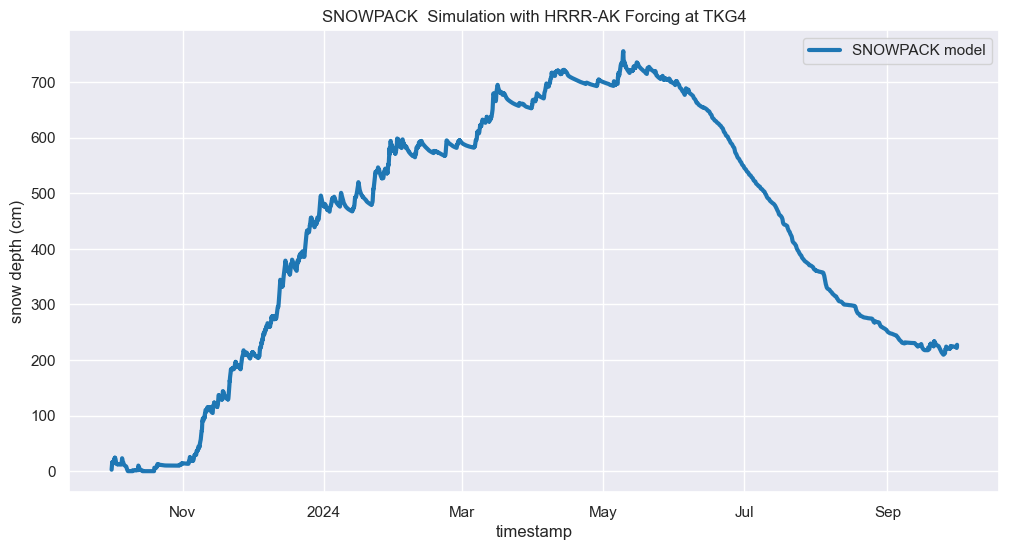

In [25]:
ds_snowpack_WY2024.HS_mod.plot(label = 'SNOWPACK model', linewidth = 3, color='tab:blue')

plt.title('SNOWPACK  Simulation with HRRR-AK Forcing at TKG4')
plt.legend()

plt.ylabel('snow depth (cm)')

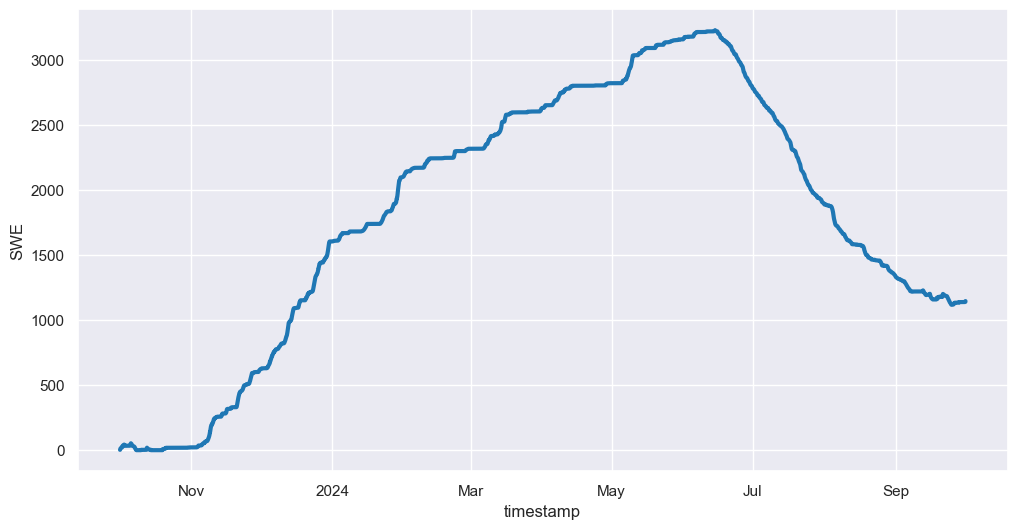

In [26]:
# plot SWE 
ds_snowpack_WY2024.SWE.plot(label = 'SNOWPACK model WY2024', linewidth = 3, color='tab:blue')

## Load Simulations from WY2024-25 Combined 

In [27]:
ds_snowpack_WY2024_25, header = read_smet("/home/cassie/python/models/run_snowpack/sites/tkg4/output/hrrrak_tkg4_WY2024-25_heatflux_soiltemp_zero.smet")

/tmp/ipykernel_3190753/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


Text(0, 0.5, 'snow depth (cm)')

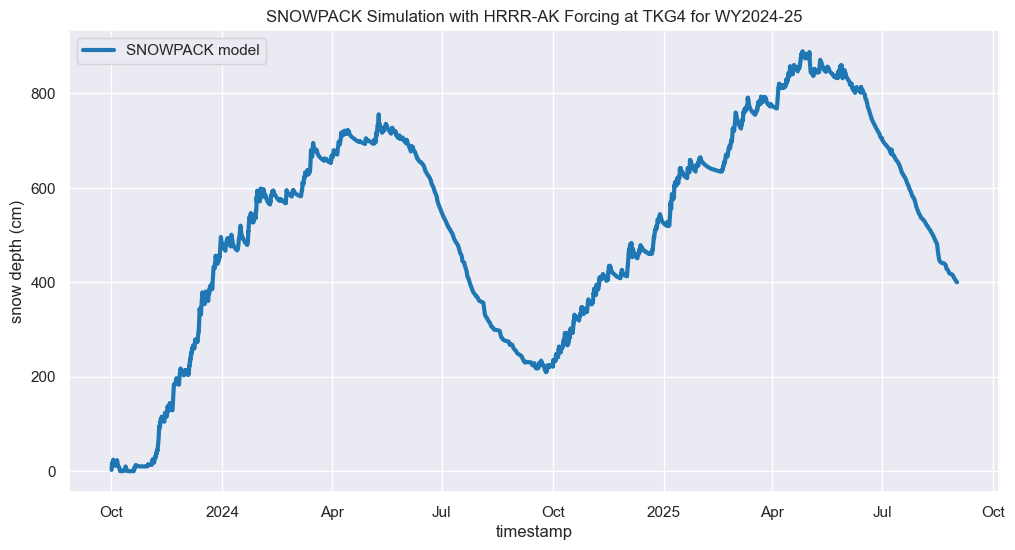

In [28]:
ds_snowpack_WY2024_25.HS_mod.plot(label = 'SNOWPACK model', linewidth = 3, color='tab:blue')

plt.title('SNOWPACK Simulation with HRRR-AK Forcing at TKG4 for WY2024-25')
plt.legend()

plt.ylabel('snow depth (cm)')

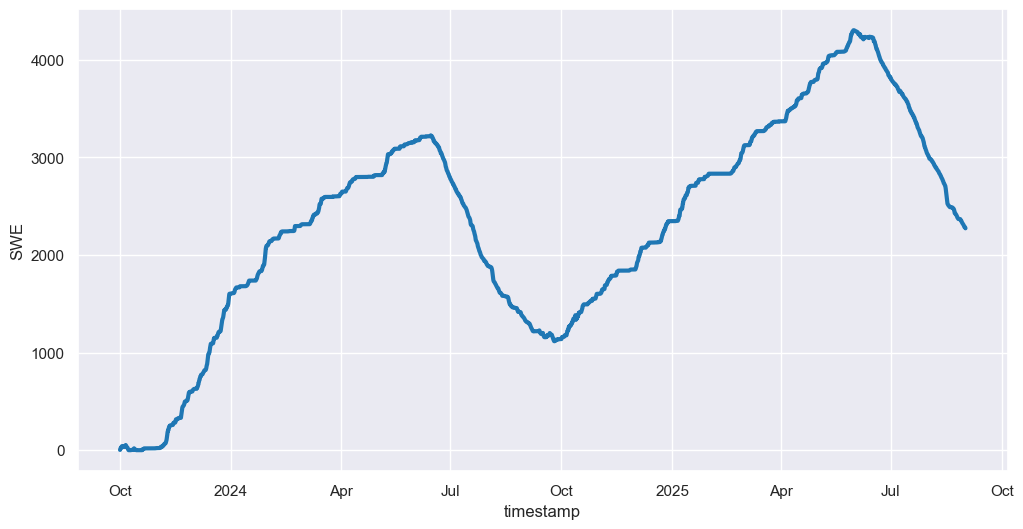

In [29]:
# plot SWE 
ds_snowpack_WY2024_25.SWE.plot(label = 'SNOWPACK model', linewidth = 3, color='tab:blue')

In [46]:
df_field

,date,site,core_depth_cm,snow_firm_transition_depth_cm
0,2024-06-15,TKG4,800,642.5


Text(0, 0.5, 'snow depth (cm)')

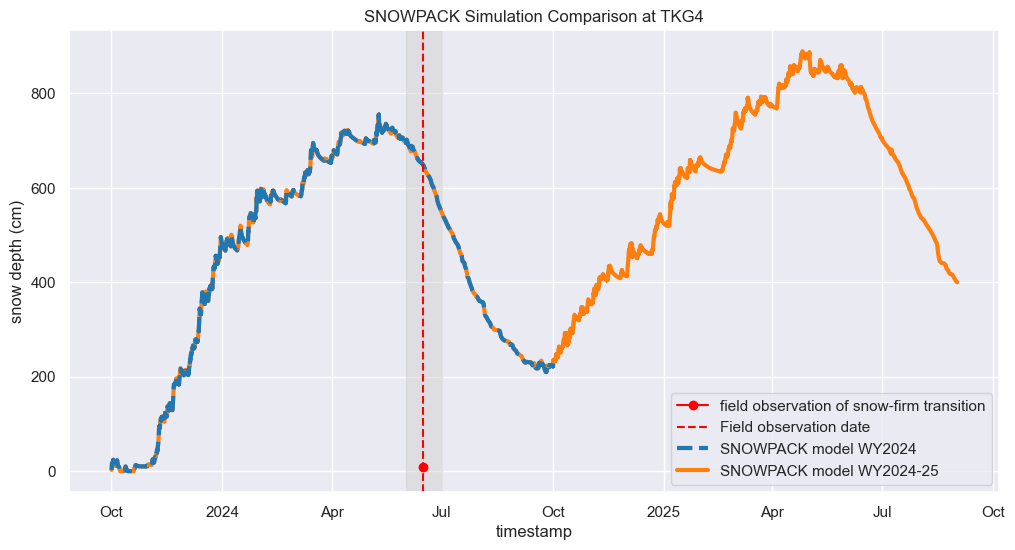

In [55]:
# and plot ds_snowpack and ds_snowpack_2 together for comparison
ds_snowpack_WY2024_25.HS_mod.plot(label = 'SNOWPACK model WY2024-25', linewidth = 3, color='tab:orange')
ds_snowpack_WY2024.HS_mod.plot(label = 'SNOWPACK model WY2024', linewidth = 3, color='tab:blue', linestyle='--')

# highlight the space between June 1 and July 1 in light grey fill
plt.axvspan('2024-06-01', '2024-07-01', color='lightgrey', alpha=0.5)

# add a vertical line at June 15, 2024 to indicate the date of the field observation
plt.axvline(df_field['date'].iloc[0], color='red', linestyle='--', label='Field observation date')

# add the snow depth measurement as a red marker at the date of the field observation
# take the simulation snow depth from June 15 2024 and subtract the snow-firm transition depth to get the snow depth above the snow-firm transition, which is what we observed in the field
snow_depth_WY2024 = ds_snowpack_WY2024.HS_mod.sel(timestamp=df_field['date'].iloc[0], method='nearest').values
snow_depth_WY2024_above_transition = snow_depth_WY2024 - df_field['snow_firm_transition_depth_cm'].iloc[0]
plt.plot(df_field['date'].iloc[0], snow_depth_WY2024_above_transition, marker='o', color='red', label='field observation of snow-firm transition')

# plot df snow-firm 
# plt.plot(df_field['date'], df_field['snow_firm_transition_depth_cm'], marker='o', color='red', label='field observation of snow-firm transition')

plt.title('SNOWPACK Simulation Comparison at TKG4')

# show the legend in the reverse order 
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1])
plt.ylabel('snow depth (cm)')

In [ ]:
# what is the modeled snow depth on June 15, 2024 in each simulation?
snow_depth_on_June_15_2024 = ds_snowpack_WY2024.HS_mod.sel(timestamp=df_field['date'].iloc[0], method='nearest').values

# print the value for the snow depth on June 15, 2024 for the WY2024 simulation
print(f"Modeled snow depth on June 15, 2024: {snow_depth_on_June_15_2024:.2f} cm")
# print the value for the firn-snow transiation depth on June 15, 2024 in df_field
print(f"Field observation of snow-firm transition depth on June 15, 2024: {df_field['snow_firm_transition_depth_cm'].iloc[0]:.2f} cm")

Modeled snow depth on June 15, 2024: 650.34 cm
Field observation of snow-firm transition depth on June 15, 2024: 642.50 cm


Text(0, 0.5, 'snow water equivalent (mm)')

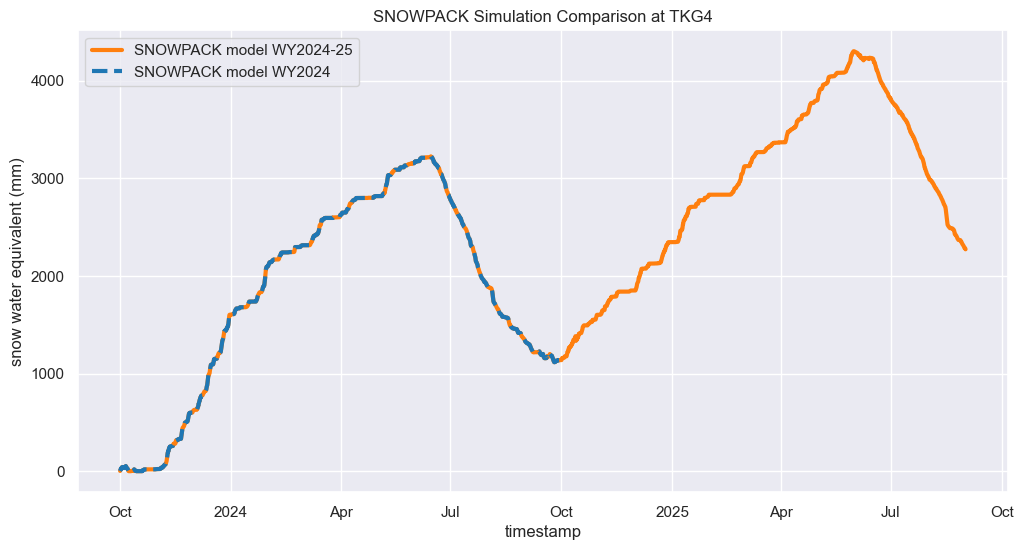

In [37]:
# and plot ds_snowpack and ds_snowpack_2 together for comparison
ds_snowpack_WY2024_25.SWE.plot(label = 'SNOWPACK model WY2024-25', linewidth = 3, color='tab:orange')
ds_snowpack_WY2024.SWE.plot(label = 'SNOWPACK model WY2024', linewidth = 3, color='tab:blue', linestyle='--')

plt.title('SNOWPACK Simulation Comparison at TKG4')
plt.legend()
plt.ylabel('snow water equivalent (mm)')